In [208]:
import random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.colors import ListedColormap
from sklearn import metrics
from sklearn.datasets import make_circles, make_blobs, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "C:\Slava\spbu_ml_2026\data"

<>:41: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:41: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\Slava Bek\AppData\Local\Temp\ipykernel_17676\1884760422.py:41: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  data_path = "C:\Slava\spbu_ml_2026\data"


Рассмотрим набор данных о качестве вина на основе различных химических показателей. Есть всего 6 значений качества, поэтому задачу проще всего решать классификацией.

In [209]:
df = pd.read_csv(data_path+'/'+"winequality-red.csv", sep=",")

In [210]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Несбалансированные данные
Несбалансированные данные - это одна из наиболее распространенных проблем, с которой сталкиваются в машинном обучении. Они возникают, когда классы, которые мы пытаемся предсказать, представлены неравномерно. Другими словами, один класс имеет гораздо меньше примеров, чем другой, что создает дисбаланс в распределении данных.
Деревья решений очень уязвимы перед дисбалансом классов, так как используют вероятности в критериях разбиения.

**Задание**: Определите, сколько в датасете примеров хорошего вина (оценка 7 и выше) и плохого (3) в процентах от общего количества

In [211]:
total = len(df)
good = (df['quality'] >= 7).sum()
bad = (df['quality'] == 3).sum()
good_pct = good / total * 100
bad_pct = bad / total * 100
print(f"Good vine: {good_pct:.2f}%")
print(f"Bad vine: {bad_pct:.2f}%")

Good vine: 13.57%
Bad vine: 0.63%


**Задание**: Создайте новый признак "good_quality", чтобы выделить именно хорошее вино

In [212]:
good_quality = df['quality'] >= 7
bad_quality = ~good_quality
y_binarized = good_quality.astype(int)

In [213]:
y_binarized = (df['quality'] >= 7).astype(int)

In [214]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)

model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

model_b = DecisionTreeClassifier(random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score after binarization is: ", model_b.score(X_train, y_train_b))
print("Test score after binarization is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.640625
Train score after binarization is:  1.0
Test score after binarization is:  0.859375


Для работы с дисбалансом есть много методов. Вы наверняка слышали про взвешивание функции потерь, вероятно, что и про овер- или андерсемплинг тоже. Казалось бы - подбери хороший метод для оверсемплинга, аугментируй данные и радуйся. Но все же оказывается, что дисбаланс - тема более глубокая, чем может показаться на первый взгляд.

Дисбаланс - это естественное свойство. Проблемы заключаются не в самом дисбалансе как таковом, а в разных ступенях работы с данными. 

Например, самые неприятные проблемы - что классификатор начинает предсказывать константу. В таком случае дело в лоссе и пороге бинаризации или неправильно построенной валидации.

Если окаывается, что цена ошибки для одного из классов большая (в ту или иную сторону), то вопрос в корректном выборе метрик.
 
Может быть такое, что проблема в сдвиге распределений между обучающей выборкой и тестовой - тогда необходимо преобразовании процедуры валидации.


### Метрики
Так как данные несбалансированные, уместно ли использовать встроенное значение score для оценки модели? На самом деле, и да и нет, так как score возвращает усредненную точность по классам. Однако еще более информатиными будут F1-мера и другие более подробные оценки.
Формула Precision:
\begin{equation}
\text{Precision} = \frac{\text{TP}}{ \text{TP} + \text{FP} }
\end{equation}
Precision наиболее полезна, если цена FP велика. Примеры такой задачи - детекция спама. В случае, если полезное письмо попадет в спам, юзер может потерять важную информацию, что нежелательно.
Формула Recall:
\begin{equation}
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
\end{equation}
Recall наиболее полезна, если цена FN велика. Она поможет, если нам необходимо найти всех больных пациентов, определить фрод и т.д.
Вопрос: что отражают две эти метрики?


Формула F1-метрики:
\begin{equation}
\text{F1} = \frac{2 * \text{TP}}{2 * \text{TP} + \text{FP} + \text{FN}}
\end{equation}
F1-метрика может быть выведена из precision и recall и позволяет найти баланс между ними. 

**Задание**: определите, как f1 выводится из precision и recall.

F1-score выражается через precision и recall как их гармоническое среднее: F1 = (2 · Precision · Recall) / (Precision + Recall)
Смысл в том, что F1 будет высоким только тогда, когда и precision, и recall одновременно высокие. Если один из них маленький, F1 тоже сильно уменьшается.

Существует и болеее общая оценка - $F_\beta$. Она позволяет получить взвешенное среднее между precision и recall. Ее формулу дадим на занятии. Наиболее популярные параметры - 2 и 0.5.
Тут тоже есть особенности. Метрики бывают нескольких видов, в зависимости от того, как учитываются разные классы:
- микро - метрики считаются глобально сразу по всем классам.
- макро - вначале считаются для каждого класса, потом берется среднее ($F1_{macro} = \frac{1}{K}\sum_{k=1}^{K}F1_k$)
- взвешенные по классам - вначале считаются для каждого класса, потом берется среднее, взвешенное по поддержке

Вопрос: какой способ вычисления лучше всего выбрать при дисбалансе классов? Покажите на примере.

### Синтетика: Fraud-like (минимизируем число пропусков)

Постановка: бинарная классификация транзакций, где мошенничество встречается редко. Пусть классы умеренно перекрываются, а `flip_y` имитирует ошибки в исторических данных. Нам важно не пропустить миноритарный класс.

Будем сравнивать модели, обученные без учета дисбаланса классов, и с учетом веса классов в функции потерь. 

In [215]:
from sklearn.ensemble import RandomForestClassifier


def evaluate_imbalance_models(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    model: str = "LR",
    thresholds: list[float] = [0.2, 0.5, 0.7],
    random_state: int = 42,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    if model == "LR":
        model_class = LogisticRegression
    else:
        model_class = RandomForestClassifier
        
    models = {
        f"Baseline {model}": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model_class(random_state=random_state)),
        ]),
        f"ClassWeight {model}": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model_class(class_weight="balanced", random_state=random_state)),
        ]),

    }

    rows = []
    conf_mats = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]

        for threshold in thresholds:
            pred_name = f"{model_name} (threshold={threshold})"
            y_pred = (y_proba >= threshold ).astype(int)
            rows.append(
                {
                    "model": pred_name,
                    "accuracy": accuracy_score(y_test, y_pred),
                    "precision": precision_score(y_test, y_pred, zero_division=0),
                    "recall": recall_score(y_test, y_pred, zero_division=0),
                    "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
                    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
                    "pr_auc": average_precision_score(y_test, y_proba),
                }
            )
            conf_mats[pred_name] = confusion_matrix(y_test, y_pred)

    result = pd.DataFrame(rows)  # .sort_values(["f1_macro", "recall"], ascending=False)
    return result.reset_index(drop=True), conf_mats

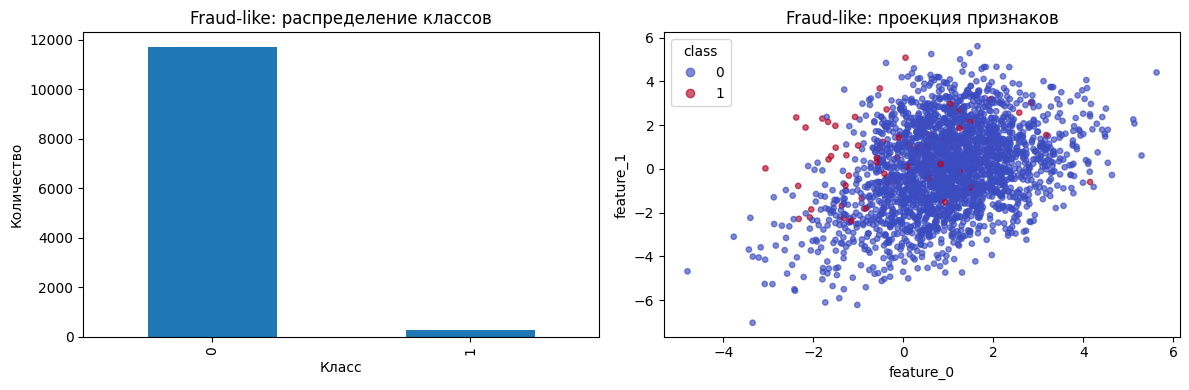

In [216]:
X_fraud, y_fraud = make_classification(
    n_samples=12000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=2,
    weights=[0.98, 0.02],
    class_sep=1.0,
    flip_y=0.01,
    random_state=SEED,
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.25,
    stratify=y_fraud,
    random_state=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_fraud).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Fraud-like: распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")

sample_idx = np.random.RandomState(SEED).choice(np.arange(len(X_fraud)), size=2500, replace=False)
scatter = axes[1].scatter(
    X_fraud[sample_idx, 0],
    X_fraud[sample_idx, 1],
    c=y_fraud[sample_idx],
    cmap="coolwarm",
    alpha=0.65,
    s=15,
)
axes[1].set_title("Fraud-like: проекция признаков")
axes[1].set_xlabel("feature_0")
axes[1].set_ylabel("feature_1")
axes[1].legend(*scatter.legend_elements(), title="class")

plt.tight_layout()
plt.show()


In [217]:
fraud_metrics, fraud_conf = evaluate_imbalance_models(Xf_train, Xf_test, yf_train, yf_test, "LR", random_state=SEED)
fraud_metrics

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline LR (threshold=0.2),0.976667,0.491228,0.405797,0.976667,0.716264,0.416434
1,Baseline LR (threshold=0.5),0.979667,0.722222,0.188406,0.979667,0.644267,0.416434
2,Baseline LR (threshold=0.7),0.979333,0.818182,0.130435,0.979333,0.607264,0.416434
3,ClassWeight LR (threshold=0.2),0.419667,0.036585,0.956522,0.419667,0.324310,0.321243
4,ClassWeight LR (threshold=0.5),0.844333,0.105159,0.768116,0.844333,0.549470,0.321243
5,ClassWeight LR (threshold=0.7),0.939667,0.214286,0.608696,0.939667,0.642710,0.321243


In [218]:
fraud_metrics, fraud_conf = evaluate_imbalance_models(Xf_train, Xf_test, yf_train, yf_test, "RF", random_state=SEED)
fraud_metrics

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline RF (threshold=0.2),0.981667,0.592105,0.652174,0.981667,0.805648,0.643508
1,Baseline RF (threshold=0.5),0.984000,0.956522,0.318841,0.984000,0.735068,0.643508
2,Baseline RF (threshold=0.7),0.980333,1.000000,0.144928,0.980333,0.621600,0.643508
3,ClassWeight RF (threshold=0.2),0.985000,0.676471,0.666667,0.985000,0.831929,0.630055
4,ClassWeight RF (threshold=0.5),0.980333,0.777778,0.202899,0.980333,0.655931,0.630055
5,ClassWeight RF (threshold=0.7),0.977333,1.000000,0.014493,0.977333,0.508552,0.630055


In [219]:
fraud_metrics[fraud_metrics["model"].map(lambda x: x.find("RF") > -1)]

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline RF (threshold=0.2),0.981667,0.592105,0.652174,0.981667,0.805648,0.643508
1,Baseline RF (threshold=0.5),0.984000,0.956522,0.318841,0.984000,0.735068,0.643508
2,Baseline RF (threshold=0.7),0.980333,1.000000,0.144928,0.980333,0.621600,0.643508
3,ClassWeight RF (threshold=0.2),0.985000,0.676471,0.666667,0.985000,0.831929,0.630055
4,ClassWeight RF (threshold=0.5),0.980333,0.777778,0.202899,0.980333,0.655931,0.630055
5,ClassWeight RF (threshold=0.7),0.977333,1.000000,0.014493,0.977333,0.508552,0.630055


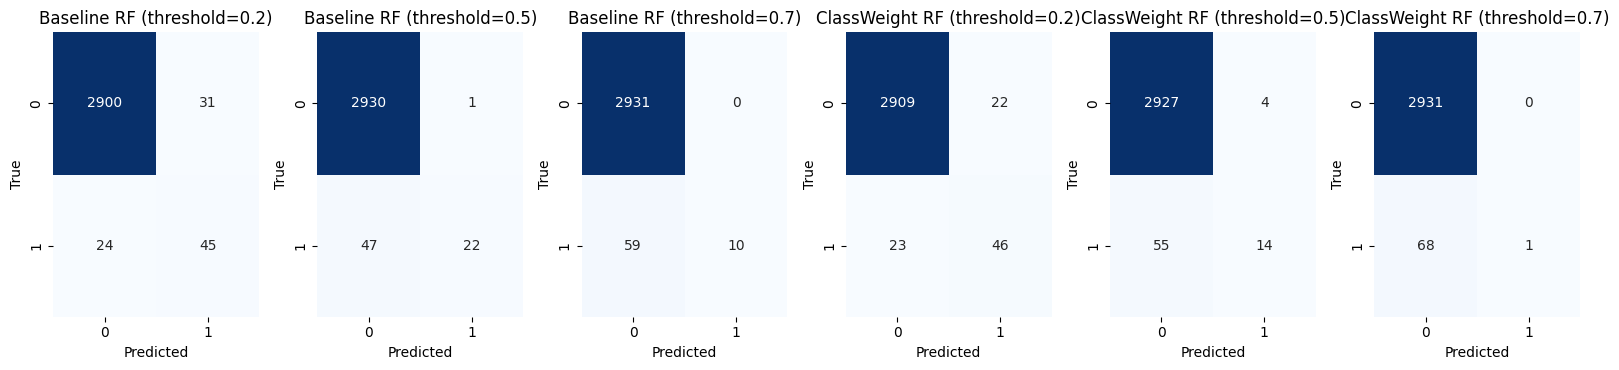

In [220]:
fig, axes = plt.subplots(1, len(fraud_conf), figsize=(16, 3.8))

for ax, model_name in zip(axes, fraud_conf.keys()):
    sns.heatmap(fraud_conf[model_name], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

Мы явно видим, что бейзлайн с высоким порогоим может иметь хороший `f1_micro`, но низкий `recall` . При снижении порога и/или балансировке (`class_weight`) recall растет, а вместе с ним и `f1_macro`, но возрастает число ложноположительных срабатываний. При этом попытка использовать балансировку классов приводит к очень большому числу ложных срабатываний (что хотя и не так плохо при наличии нескольких фильтров, может быть нежелательно). 

### Снова wine quality

In [221]:
print("Train f1-score is: ", f1_score(y_train, model.predict(X_train), average="micro"))
print("Test f1-score is: ", f1_score(y_test, model.predict(X_test), average="micro"))

Train f1-score is:  1.0
Test f1-score is:  0.640625


In [222]:
print("Train f1-score (binary) is: ", f1_score(y_train_b, model_b.predict(X_train), average="micro"))
print("Test f1-score  (binary) is: ", f1_score(y_test_b, model_b.predict(X_test), average="micro"))

Train f1-score (binary) is:  1.0
Test f1-score  (binary) is:  0.859375


In [223]:

print("Train f1-score is: ", f1_score(y_train, model.predict(X_train), average="macro"))
print("Test f1-score is: ", f1_score(y_test, model.predict(X_test), average="macro"))

Train f1-score is:  1.0
Test f1-score is:  0.4303156202512262


In [224]:
print("Train f1-score (binary) is: ", f1_score(y_train_b, model_b.predict(X_train), average="macro"))
print("Test f1-score (binary) is: ", f1_score(y_test_b, model_b.predict(X_test), average="macro"))

Train f1-score (binary) is:  1.0
Test f1-score (binary) is:  0.7311376239287515


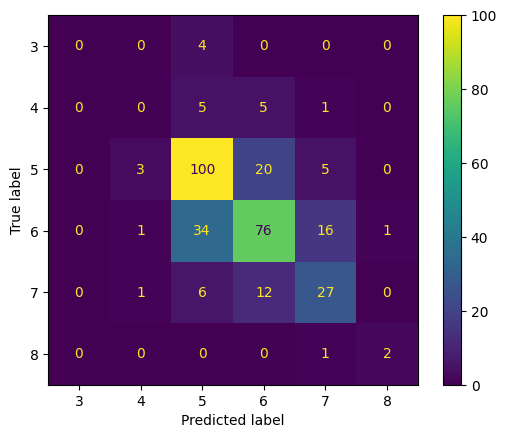

In [225]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

Давайте руками рассмотрим, как оценивается точность и почему нам сложно получить адекватную оценку при сильном дисбалансе.

In [226]:
metrics_df = pd.DataFrame(columns=['label', 'TP', 'TN', 'FP', 'FN', 'support', 'accuracy', 'precision', 'recall'])

In [227]:
from sklearn.utils import compute_class_weight
classes = np.unique(y_train)
classes.sort()
print(classes)

[3 4 5 6 7 8]


In [228]:
y_pred = model.predict(X_test)

**Задание**: Закончите код для рассчета метрик по классам.

In [229]:
metrics_df = pd.DataFrame()

for class_id in classes:
    class_stats = {}
    class_stats["label"] = class_id

    gt = X_test.loc[y_test == class_id]
    class_stats["support"] = len(gt)

    true_mask = (y_test == class_id)
    pred_mask = (y_pred == class_id)

    TP = (true_mask & pred_mask).sum()
    FP = (~true_mask & pred_mask).sum()
    FN = (true_mask & ~pred_mask).sum()
    TN = (~true_mask & ~pred_mask).sum()

    class_stats["TP"] = TP
    class_stats["FP"] = FP
    class_stats["FN"] = FN
    class_stats["TN"] = TN

    class_stats["accuracy"]  = (TP + TN) / len(y_test) if len(y_test) > 0 else 0
    class_stats["precision"] = TP / (TP + FP) if (TP + FP) > 0 else 0
    class_stats["recall"]    = TP / (TP + FN) if (TP + FN) > 0 else 0  

    metrics_df = pd.concat([metrics_df, pd.DataFrame(class_stats, index=[0])], ignore_index=True)

metrics_df

,label,support,TP,FP,FN,TN,accuracy,precision,recall
0,3,4,0,0,4,316,0.987500,0.000000,0.000000
1,4,11,0,5,11,304,0.950000,0.000000,0.000000
2,5,128,100,49,28,143,0.759375,0.671141,0.781250
3,6,128,76,37,52,155,0.721875,0.672566,0.593750
4,7,46,27,23,19,251,0.868750,0.540000,0.586957
5,8,3,2,1,1,316,0.993750,0.666667,0.666667


**Задание**: Посчитайте макро-метрики. 

In [230]:
macro_metrics = {
    "macro precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "macro recall": recall_score(y_test, y_pred, average="macro"),
    "macro f1": f1_score(y_test, y_pred, average="macro"),
}

print(pd.DataFrame([macro_metrics]))

   macro precision  macro recall  macro f1
0         0.425062      0.438104  0.430316


**Задание со звездочкой**: Посчитайте микро-метрики. 

In [231]:
micro_metrics = {
    "micro precision": precision_score(y_test, y_pred, average="micro"),
    "micro recall": recall_score(y_test, y_pred, average="micro"),
    "micro f1": f1_score(y_test, y_pred, average="micro"),
}

print(pd.DataFrame([micro_metrics]))

   micro precision  micro recall  micro f1
0         0.640625      0.640625  0.640625


F-мера позволяет сравнивать между собой модели, используя лишь одно число. Однако она и подобные ей метрики не всегда верно отражают действительность (мы уже частично это поняли). Но важно, что они могут расти больше из-за того, что прогнозы становятся нетривиальными! Например, пусть у нас есть 2 ящика, в каждом из них по 9 груш и 1 яблоку. Мы вытаскиваем за ход один фрукт из случайного ящика. Нам нужно угадать, какой это будет фрукт. Тогда, допустим:
1) Маша всегда говорит, что фрукт - груша. Точность такого прогноза - $0.5*0.9 + 0.5*0.9 = 0.9$. F1 при этом будет равна 0 (почему мы не гооврим про микро- и макро- случаи здесь?)
2) Вася говорит, что фрукт из первого ящика - груша, а из второго - яблоко. Точность такого прогноза - $0.5*0.9 + 0.5*0.1 = 0.5$. F1 будет уже $2 \over {2 + 9 + 1} = 0.166$

Оба не умеют угадывать фрукт, но Вася при этом выигрывает :(



## Imbalanced learning

Как заставить модель учиться так, чтобы учитывать все классы? Самое простое - задать вес класса. Мы уже проделали это на синтетике, проделаем и на датасете по вину.

In [232]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

model_b = RandomForestClassifier(random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score after binarization is: ", model_b.score(X_train, y_train_b))
print("Test score after binarization is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.678125
Train score after binarization is:  1.0
Test score after binarization is:  0.9


Вопрос: Какие есть хорошие способы это сделать?

class_weight="balanced" — автоматически задаёт веса обратно пропорционально частоте классов

ручные веса — явное задание важности классов через sample_weight или формулы частот

oversampling (SMOTE, ADASYN) — увеличение числа объектов редких классов

undersampling — уменьшение числа объектов доминирующих классов

macro-F1 / balanced accuracy — использование правильных метрик при обучении и подборе моделей

In [233]:
class_weights = {
    c: len(X_train) / len(X_train[y_train == c])
    for c in classes
}

model = RandomForestClassifier(class_weight=class_weights, random_state=0)
model.fit(X_train, y_train)

print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

Train score: 1.0
Test score: 0.6875


In [234]:
class_weights

{np.int64(3): 213.16666666666666,
 np.int64(4): 30.452380952380953,
 np.int64(5): 2.3128390596745025,
 np.int64(6): 2.507843137254902,
 np.int64(7): 8.359477124183007,
 np.int64(8): 85.26666666666667}

In [235]:
model_b = RandomForestClassifier(class_weight={i: len(X_train)/len(X_train.loc[y_train_b==i]) for i in [0,1]}, random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score is: ", model_b.score(X_train, y_train_b))
print("Test score is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.89375


In [236]:
print("Train micro f1-score is: ", f1_score(y_train, model.predict(X_train), average="micro"))
print("Test micro f1-score is: ", f1_score(y_test, model.predict(X_test), average="micro"))
print("Train macro f1-score is: ", f1_score(y_train, model.predict(X_train), average="macro"))
print("Test macro f1-score is: ", f1_score(y_test, model.predict(X_test), average="macro"))

Train micro f1-score is:  1.0
Test micro f1-score is:  0.6875
Train macro f1-score is:  1.0
Test macro f1-score is:  0.3426142790892566


In [237]:
print("Train micro (binary) f1-score is: ", f1_score(y_train_b, model_b.predict(X_train), average="micro"))
print("Test micro (binary) f1-score is: ", f1_score(y_test_b, model_b.predict(X_test), average="micro"))
print("Train macro (binary) f1-score is: ", f1_score(y_train_b, model_b.predict(X_train), average="macro"))
print("Test macro (binary) f1-score is: ", f1_score(y_test_b, model_b.predict(X_test), average="macro"))

Train micro (binary) f1-score is:  1.0
Test micro (binary) f1-score is:  0.89375
Train macro (binary) f1-score is:  1.0
Test macro (binary) f1-score is:  0.7461739455020531


Выведем, как изменились предсказания модели.

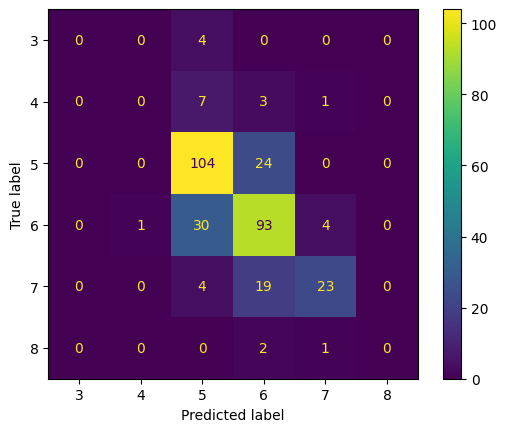

In [238]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

Также посмотрим, насколько чувствительна к дисбалансу другая модель - LogisticRegression

In [239]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [240]:
logreg = make_pipeline(StandardScaler(), LogisticRegression())
logreg.fit(X_train, y_train)

print("train score:", logreg.score(X_train, y_train))
print("test score:", logreg.score(X_test, y_test))
print("classes:", logreg.classes_)

train score: 0.6106333072713057
test score: 0.596875
classes: [3 4 5 6 7 8]


In [241]:
class_weights = {
    c: len(X_train) / len(X_train[y_train == c])
    for c in np.unique(y_train)
}

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight=class_weights)
)

logreg.fit(X_train, y_train)

print("train score:", logreg.score(X_train, y_train))
print("test score:", logreg.score(X_test, y_test))

train score: 0.44566067240031276
test score: 0.446875


Как видно, балансировка не всегда одинаково полезна. Однако мы можем попробовать воспользоваться дополнительными методами для обучения нашей модели. Это будет андер- и оверсемплинг (балансировка датасета). Идея балансировки данных проста - мы делаем классы сбалансированными, либо заменяя большой класс подвыборкой, близкой к  малому классу, либо же увеличиваем в размерах малый класс с помощью синтетики.


Самое простое - взять только небольшую, но сбалансированную часть обучающих данных для непосредственного обучения, взяв случайную подвыборку большрого класса. Однако, для нашего случая это плохо подходит, так как данных довольно мало. (На самом деле, даже в такой ситуации это может быть полезно, чтобы обучить ансамбли моделей, обученных на разных обрезанных выборках). В случае же оверсемплинга самый простой способ - продублировать объекты малого класса.

Еще раз вспомним, какие предсказания давал случайный лес для нашего набора

In [242]:
model = RandomForestClassifier(max_depth=5)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

print("Train f1-score is: ", f1_score(y_train, y_pred=model.predict(X_train), average="macro"))
print("Test f1-score is: ", f1_score(y_test, y_pred=model.predict(X_test), average="macro"))

Train score is:  0.7036747458952306
Test score is:  0.621875
Train f1-score is:  0.3283065274643619
Test f1-score is:  0.27989784854191635


# Оверсемплинг

Для начала проведем простейший оверсемплинг, выбирая семплы из минорного класса с заменой до достижения баланса:

In [243]:
def print_counts(y) -> None:
    unique, counts = np.unique(y, return_counts=True)
    print("\n".join([f"{u}: {c}" for u, c in zip(unique, counts)]))

In [244]:
print_counts(y_train) 

3: 6
4: 42
5: 553
6: 510
7: 153
8: 15


In [245]:
ros = RandomOverSampler(random_state=SEED)
X_res, y_res = ros.fit_resample(X_train, y_train)
model = RandomForestClassifier(max_depth=5, random_state=SEED)
model.fit(X_res, y_res)
y_pred = model.predict(X_test)

print("train score:", model.score(X_res, y_res))
print("test score:", model.score(X_test, y_test))
print("test macro f1:", f1_score(y_test, y_pred, average="macro"))

print_counts(y_res)

train score: 0.7811934900542495
test score: 0.50625
test macro f1: 0.30212509738342885
3: 553
4: 553
5: 553
6: 553
7: 553
8: 553


### SMOTE (Synthetic Minority Oversampling Technique):
SMOTE позволяет расширить выборку, построив синтетические примеры на основе уже существующих. Это еще один вариант решения «проблем классового дисбаланса». Подобный алгоритм используется в некоторых методах аугментации, например, MixUp.

Общая схема SMOTE:
1) Для создания нового семпла используют пару признаков «соседних» примеров a  и b из миноритарного класса. Их находят, используя KNN. В данном случае достаточно для семпла a получить набор из k соседей, из которого в дальнейшем будет случайно выбран семпл b.
2) Для создания нового семпла находят разность $d=X_b–X_a$, где $X_a,X_b$ – векторы признаков «соседних» примеров a  и b из миноритарного класса.
3) Далее из $d$ путем его умножения на случайное число в интервале (0,1)  получают $d'$.
4) Вектор признаков нового примера вычисляется путем сложения Xa и $d'$.

Вопрос: сколько соседей выбирать? И сколько соседей стоит использовать для каждой узловой точки?


Обычно используется k = 5 ближайших соседей — это стандартное значение в большинстве реализаций.

Для генерации каждого нового синтетического объекта:
- выбирается случайный сосед **из этих k ближайших**
- и на его основе строится новый пример

### Интуиция выбора k:

- **маленький k (3–5)** - более локальные и точные синтетические точки, но выше риск шума  
- **большой k (7–10+)** - более сглаженные данные, но может размывать структуру класса  

In [246]:
smote = SMOTE(random_state=SEED, k_neighbors=5, sampling_strategy='minority')
X_res, y_res = smote.fit_resample(X_train, y_train)
print_counts(y_res)

3: 553
4: 42
5: 553
6: 510
7: 153
8: 15


In [247]:
model = RandomForestClassifier(max_depth=5)
model.fit(X_res, y_res)
print("Train score is: ", model.score(X_res, y_res))
print("Test score is: ", model.score(X_test, y_test))
print("Test f1-score is: ", f1_score(y_test, y_pred=model.predict(X_test), average="macro"))

Train score is:  0.7782037239868566
Test score is:  0.6
Test f1-score is:  0.25850865866011646


Также мы можем получить более подробный отчет по точности модели.

In [248]:
from imblearn.metrics import classification_report_imbalanced

In [249]:
print(classification_report_imbalanced(y_test, model.predict(X_test)))

                   pre       rec       spe        f1       geo       iba       sup

          3       0.00      0.00      0.98      0.00      0.00      0.00         4
          4       0.00      0.00      1.00      0.00      0.00      0.00        11
          5       0.64      0.79      0.71      0.71      0.75      0.56       128
          6       0.57      0.66      0.66      0.61      0.66      0.44       128
          7       1.00      0.13      1.00      0.23      0.36      0.12        46
          8       0.00      0.00      1.00      0.00      0.00      0.00         3

avg / total       0.63      0.60      0.75      0.56      0.62      0.42       320



c:\Users\Slava Bek\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Рассмотрим также поведение алгоритма на синтетических данных.

### Сравнение методов over/under sampling на wine


In [250]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours

X_tr, y_tr, X_te, y_te = X_train, y_train_b, X_test, y_test_b
minority = int(np.min(np.bincount(np.asarray(y_tr))))
k = max(1, min(3, minority - 1))

methods = {
    'Over:RandomOverSampler': RandomOverSampler(random_state=SEED),
    'Over:SMOTE': SMOTE(random_state=SEED, k_neighbors=k),
    'Over:AdaSYN': ADASYN(random_state=SEED, n_neighbors=k),
    'Over:BorderlineSMOTE': BorderlineSMOTE(random_state=SEED, k_neighbors=k),
    'Under:RandomUnderSampler': RandomUnderSampler(random_state=SEED),
    'Under:NearMiss': NearMiss(version=1, n_neighbors=k),
    'Under:TomekLinks': TomekLinks(),
    'Under:EditedNearestNeighbours': EditedNearestNeighbours(n_neighbors=k)
}

rows = []
for name, sampler in methods.items():
    X_res, y_res = sampler.fit_resample(X_tr, y_tr)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
    clf.fit(X_res, y_res)
    pred = clf.predict(X_te)
    rows.append((name, f1_score(y_te, pred, average='macro'), f1_score(y_te, pred, average='micro')))

pd.DataFrame(rows, columns=['method', 'f1_macro', 'f1_micro']).sort_values('f1_macro', ascending=False)


,method,f1_macro,f1_micro
1,Over:SMOTE,0.701317,0.796875
0,Over:RandomOverSampler,0.698192,0.784375
4,Under:RandomUnderSampler,0.689424,0.781250
2,Over:AdaSYN,0.686495,0.778125
3,Over:BorderlineSMOTE,0.685894,0.787500
7,Under:EditedNearestNeighbours,0.670228,0.821875
6,Under:TomekLinks,0.664306,0.850000
5,Under:NearMiss,0.515670,0.575000


Задание: Проанализируйте также поведение на make_moons. Сделайте выводы.

f1 macro (no smote): 0.8844036697247707
f1 macro (smote): 0.8393512851897185


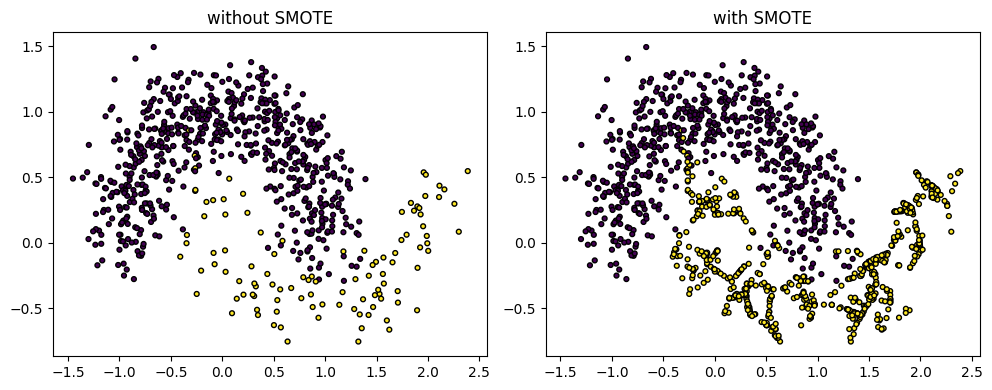

In [251]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=(900, 150), noise=0.2, random_state=SEED)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

# baseline
base = make_pipeline(StandardScaler(), LogisticRegression())
base.fit(X_tr, y_tr)
pred_base = base.predict(X_te)

# smote
sm = SMOTE(random_state=SEED)
X_sm, y_sm = sm.fit_resample(X_tr, y_tr)

sm_model = make_pipeline(StandardScaler(), LogisticRegression())
sm_model.fit(X_sm, y_sm)
pred_sm = sm_model.predict(X_te)

print("f1 macro (no smote):", f1_score(y_te, pred_base, average="macro"))
print("f1 macro (smote):", f1_score(y_te, pred_sm, average="macro"))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, s=12, edgecolor="k")
ax[0].set_title("without SMOTE")

ax[1].scatter(X_sm[:, 0], X_sm[:, 1], c=y_sm, s=12, edgecolor="k")
ax[1].set_title("with SMOTE")

plt.tight_layout()
plt.show()

На графиках видно, что после применения SMOTE увеличилось количество точек желтого класса в нижнем полумесяце, то есть баланс классов стал более равномерным. При этом значение F1-macro немного снизилось, что говорит о том, что для данной геометрии данных оверсемплинг не улучшил разделимость классов линейной моделью

In [252]:
X_gen, y_gen = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1,
                           weights=[0.02, 0.05, 0.94],
                           class_sep=0.8, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X_gen, y_gen) # train test split

ros = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)


In [253]:
def plot_decision_function(X, y, clf, ax):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)

In [254]:
X_train

array([[-0.06878826, -1.8574334 ],
       [ 1.18383558,  0.59765743],
       [ 0.66497483, -0.61622223],
       ...,
       [ 0.12969122, -1.41081532],
       [-0.56170595,  0.26128687],
       [ 1.21071124, -1.48051258]], shape=(3750, 2))

In [255]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

def get_decision_boundary(X_train, y_train, features, ax=None, model="logistic"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if model == "logistic":
        classifier = LogisticRegression()
    else:
        classifier = RandomForestClassifier(max_depth=5)
        
    classifier.fit(X_train, y_train)
    plot_decision_function(X_train, y_train, classifier, ax)
    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        alpha=0.8,
        edgecolor="k"
    )

    ax.set_title(f"{classifier.__class__.__name__} on {features[0]} vs {features[1]}")
    plt.show()

In [256]:
y_train.shape

(3750,)

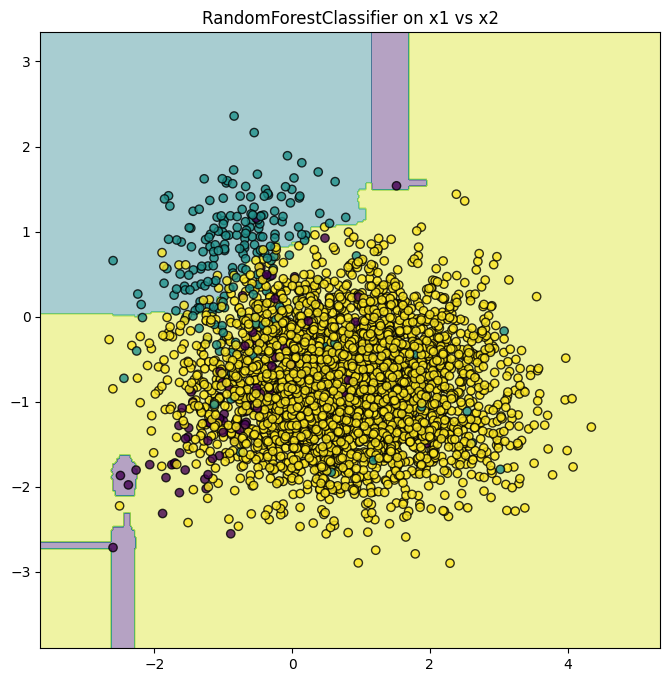

In [257]:
fig, ax = plt.subplots(figsize=(8,8))
get_decision_boundary(X_train, y_train, features = ['x1', 'x2' ], ax=ax, model="tree")

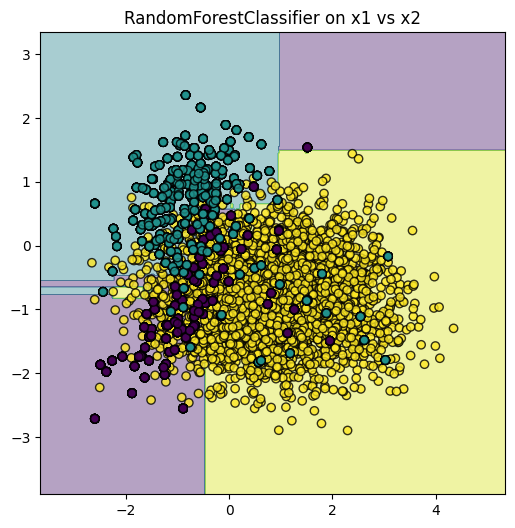

In [258]:

get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

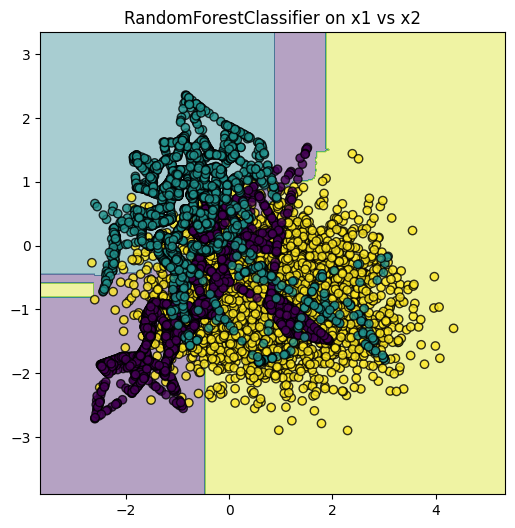

In [259]:
smote = SMOTE(random_state=SEED, k_neighbors=4)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

К сожалению, SMOTE тяготеет к генерации дубликатов, не учитывает свойства распределений классов и неустойчив к шуму. К тому же, он может генерировать невозможные примеры. 

Введем еще один метод оверсемплинга - AdaSYN (Adaptive Synthetic). Этот алгоритм, в отличие от ресэмплинга и SMOTE позволяет сгенерировать более "сложные" примеры.
Этот алгоритм работает следующим образом:
1) Рассчитывается отношение миноритарного и мажоритарного класса: $d = m_s / m_l $
2) Определяется, сколько элементов необходимо нагенерировать: $G = (m_l - m_s) * \beta $. $\beta $ - параметр балансировки
3) Для каждого семпла из миноритарного класса находятся k соседей. После чего ему присваивается вес $r_i = num\_major\_neighbours / k $.
4) $r_i$ нормализуются так, чтобы их сумма равнялсь 1: $ {r_i}' =  \frac {r_i} {\sum{r_j}}$
5) Для каждого семпла определяется число сгененрированных примеров.  $G_i = G * {r_i}' $. Вопрос: в каких областях будет генерироваться больше примеров?
6) Далее для каждого примера и его соседей генерируется синтетический пример, как в SMOTE. Также может быть использована добавка белого шума.

Вопрос: какие минусы у SMOTE и AdaSYN по отношению друг к другу?

AdaSYN генерирует больше синтетических объектов в сложных областях на границе классов, где миноритарные точки окружены мажоритарными соседями. В отличие от SMOTE, он более чувствителен к шуму и может усиливать влияние выбросов, тогда как SMOTE распределяет новые точки более равномерно.

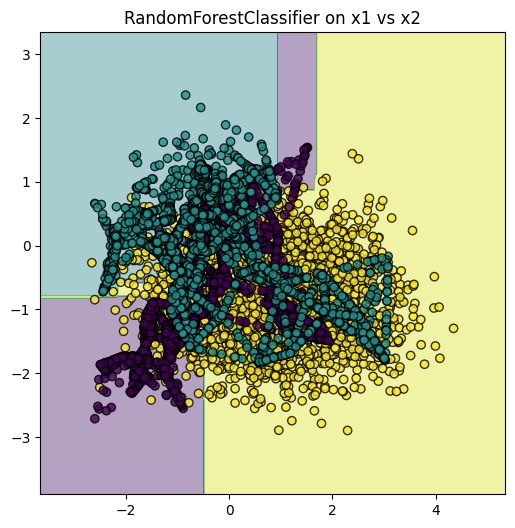

In [260]:
from imblearn.over_sampling import ADASYN
smote = ADASYN(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

На графике сразу видно, когда AdaSYN  может помешать хорошей генерации. Как видно, так как AdaSYN концентрирует сгенерированные примеры у границ классов, тогда как SMOTE может "соединять" и примеры в центральной части класса, то он может быть более удачным методом. К тому же, сущестуют различные вариации SMOTE, которые могут давать хороший рещультат в такой постановке.

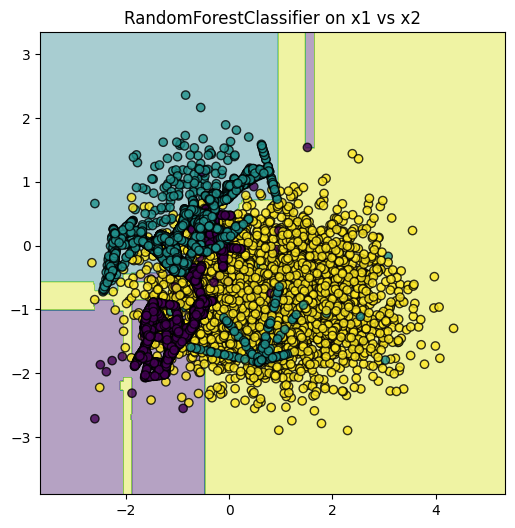

In [261]:
from imblearn.over_sampling import BorderlineSMOTE
smote = BorderlineSMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

Для того, чтобы бороться с шумом и невозможными семплами, можно добавить фильтры, объединить SMOTE с кластерингом ( и потом генерировать семплы в рамках кластера).

Вопрос: какие можно еще придумать более "умные" варианты оверсемплинга на основе CMOTE?

## Уменьшение выборки (андерсемплинг)

### Prototype generation
Методы Prototype generation (создания прототипов) позволяют сократить количество объектов в целевых классах, но остальные объектов генерируются, а не выбираются, из исходного набора.
ClusterCentroids использует для этого KMeans.

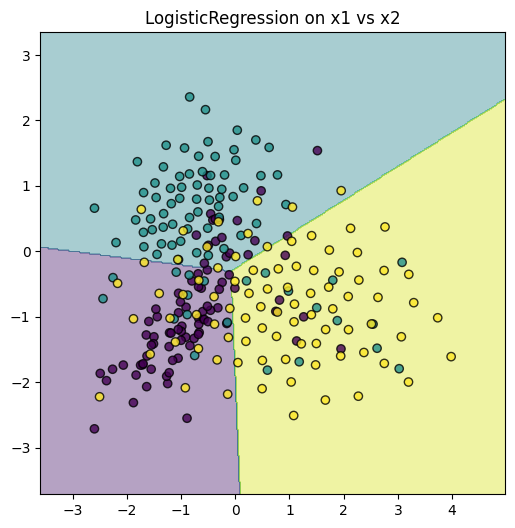

In [262]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids
sampler = ClusterCentroids(random_state=SEED, estimator=KMeans())
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ])

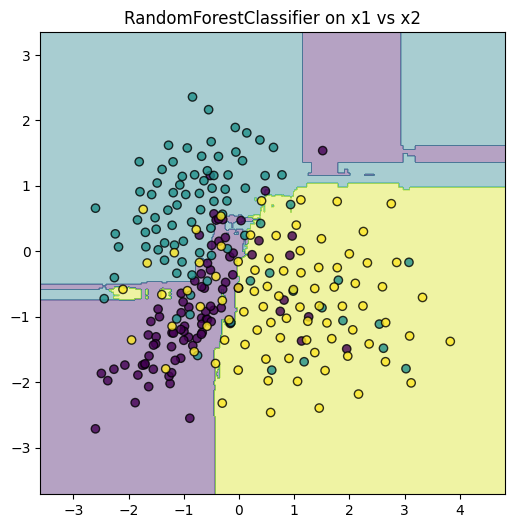

In [263]:
from imblearn.under_sampling import ClusterCentroids
sampler = ClusterCentroids(random_state=SEED, estimator=KMeans())
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

### Prototype selection
Алгоритмы Prototype selection (выбора прототипов) можно разделить на две группы: (i) методы контролируемой недостаточной выборки и (ii) методы очистки недостаточной выборки.

Методы контролируемой недостаточной выборки сокращают количество примеров в мажоритарных классах до произвольного размера. Обычно они сводят количество наблюдений к размеру миноритарного класса(ов).
К ним относятся: Random UnderSampling, NearMiss.
Напротив, методы очистки недостаточной выборки «очищают» пространство признаков, удаляя либо «зашумленные», либо «слишком легко классифицируемые» наблюдения, в зависимости от метода. Окончательное количество наблюдений в каждом классе зависит от метода очистки и не может быть указано пользователем.
К ним относится, например, метод связей Томека.


Наиболее простой метод - RandomUnderSampler - просто выкидывает семплы случайным образом.

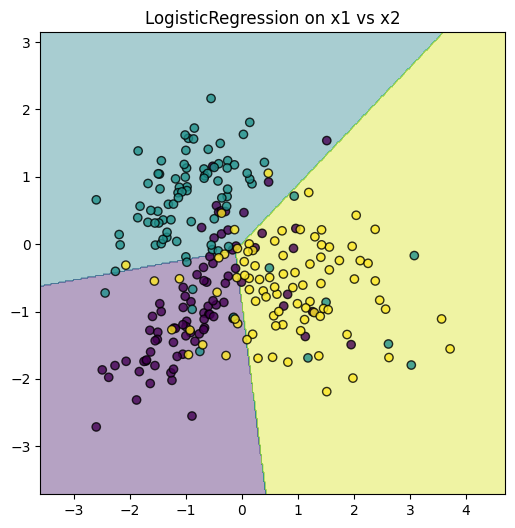

In [264]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ])

Задание: попробуйте реализовать такой семплер вручную:

before: [  85  208 3457]
after: [85 85 85]


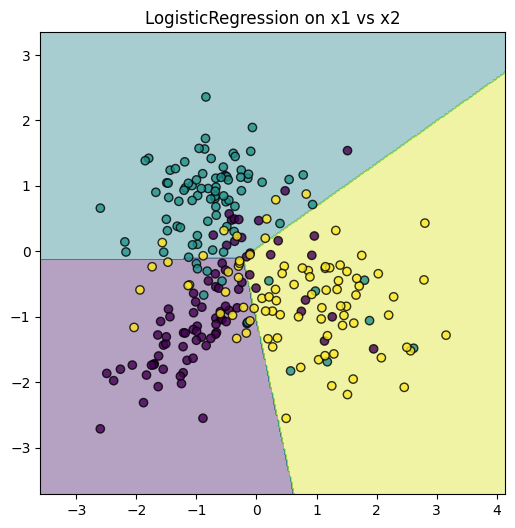

In [265]:
import numpy as np

def manual_random_undersampler(X, y, random_state=0):
    rng = np.random.RandomState(random_state)

    classes = np.unique(y)
    class_counts = {c: np.sum(y == c) for c in classes}

    min_count = min(class_counts.values())

    X_res, y_res = [], []

    for c in classes:
        idx = np.where(y == c)[0]
        chosen = rng.choice(idx, size=min_count, replace=False)
        X_res.append(X[chosen])
        y_res.append(y[chosen])

    return np.vstack(X_res), np.hstack(y_res)


print("before:", np.bincount(np.asarray(y_train)))

X_resampled, y_resampled = manual_random_undersampler(
    X_train, y_train, random_state=0
)

print("after:", np.bincount(np.asarray(y_resampled)))

get_decision_boundary(
    X_resampled,
    y_resampled,
    features=['x1', 'x2']
)

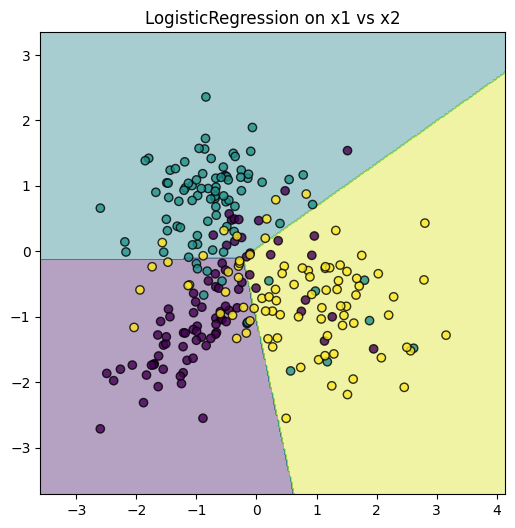

In [266]:
rng = np.random.RandomState(0)
classes = np.unique(np.asarray(y_train))
target = min([np.sum(np.asarray(y_train) == c) for c in classes])
idx = [rng.choice(np.where(np.asarray(y_train) == c)[0], size=target, replace=False) for c in classes]
idx = np.concatenate(idx)
X_resampled = np.asarray(X_train)[idx]
y_resampled = np.asarray(y_train)[idx]
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])


NearMiss добавляет некоторые эвристики для выбора семплов. Так, он может выбирать для удаления примеры, ближайшие к миноритарном классу: 
NearMiss-1 выбирает примеры, у которых наименьшее среднее расстояние до **ближайших** N примеров из миноритарного класса, а NearMiss-2 - среднее расстояние у которых до наиболее **дальних** примеров из миноритарного класса наименьшее.

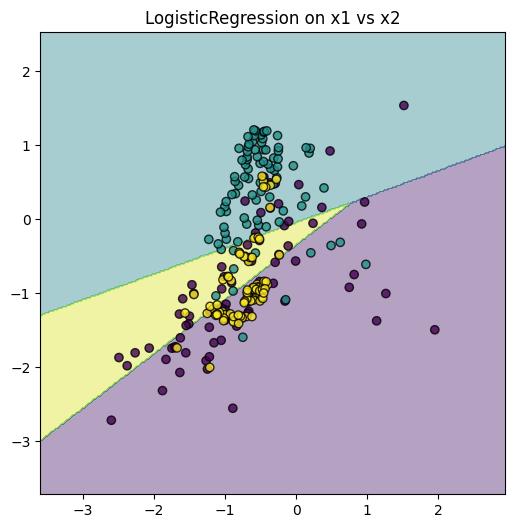

In [267]:
from imblearn.under_sampling import NearMiss
nm = NearMiss(version=1, n_neighbors=3)
X_resampled, y_resampled = nm.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])

Связь Томека существует, когда два примера из разных классов являются ближайшими соседями друг к другу. Алгоритм связей Томека детектирует такие связи и удаляет пример из мажоритарного класса. Основная идея заключается в том, что связи Томека зашумлены или наблюдения трудно классифицировать, и поэтому они не помогут алгоритму найти подходящую границу разделения.


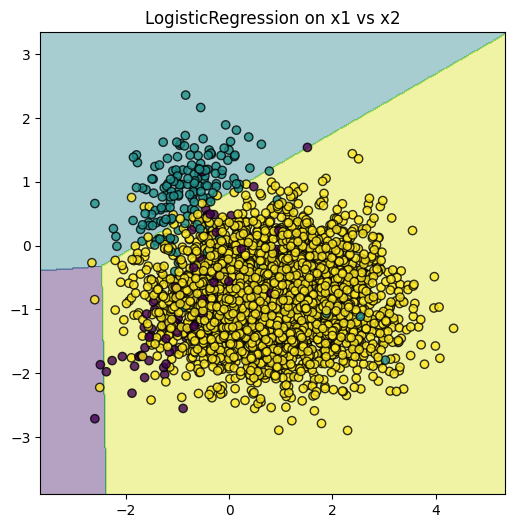

In [268]:
from imblearn.under_sampling import TomekLinks
tl = TomekLinks()
X_resampled, y_resampled = tl.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])

Edited nearest neighbours - для примеров из миноритарного класса находит k ближайших соседей и удаляет все семплы из мажоритарных классов, попавшие в эту окрестность.

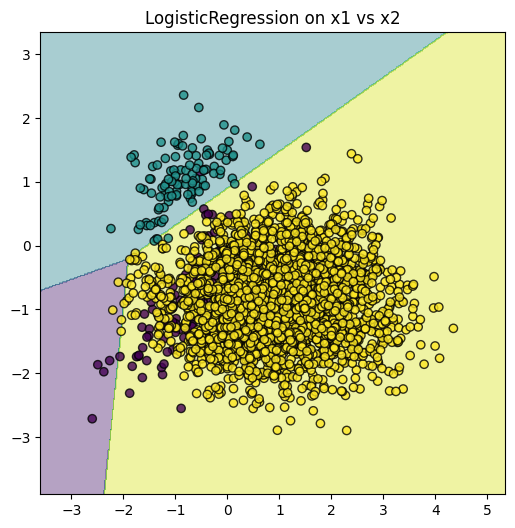

In [269]:
from imblearn.under_sampling import EditedNearestNeighbours
enn = EditedNearestNeighbours(n_neighbors=3, kind_sel='all')
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])

Нетрудно заметить, что балансировка лосса - более общая идея по отношению к оверсемплингу и андерсемплингу, при этом и гораздо более легкая в использовании. Однако идея генерации синтетики для улучшения качества модели жива и принимает разные формы. 

## Выбор порога

Как мы уже видели в ноутбуке про калибровку, хорошая модель на самом деле должна давать вероятности классов близкие к реальным. При этом метрики считаются для бинаризхованных предсказаний и могут мало соответствовать реальности. Но порог можно подбирать, простейшая стратегия - на кросс-валидации. 

In [270]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss, roc_auc_score, average_precision_score
from sklearn.model_selection import cross_val_predict

def investigate_model(model, X, y, X_test, y_test, use_cv: bool = True,  cv: int = 10):
    """
    оценить стратегию подбора порога
    """
    df = pd.DataFrame(index=['train', 'test0', 'cv', 'test', 'theta'])
    # качество бинаризации
    metrics = [accuracy_score, balanced_accuracy_score, f1_score]
    # качество оценок
    metrics2 = [log_loss, roc_auc_score, average_precision_score]

    # на cv
    if use_cv:
        a_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:,1]

    model.fit(X, y)
    
    a_train = model.predict_proba(X)[:,1]
    b_train = model.predict(X)

    a_test = model.predict_proba(X_test)[:,1]
    b_test = model.predict(X_test)
    
    # оптимальный порог по cv
    thetas = np.linspace(0, 1, 101)
    for metric in metrics:
        best_t = 0.5
        if use_cv:
            q = np.array([metric(y, a_cv > t) for t in thetas])
            i = np.argmax(q)
            best_t = thetas[i]
            s_cv = q[i]
            s_test = metric(y_test, a_test > best_t)
        else:
            s_cv = np.nan
            s_test = metric(y_test, b_test)
        sb_train = metric(y, b_train)
        sb_test = metric(y_test, b_test)
        df[metric.__name__] = [sb_train, sb_test, s_cv, s_test, best_t]

    for metric in metrics2:
        sb_train = metric(y, a_train)
        sb_test = metric(y_test, a_test)
        if use_cv:
            s_cv = metric(y, a_cv)

        df[metric.__name__] = [sb_train, sb_test, s_cv, sb_test, np.nan]
    return (df)


In [271]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)


In [272]:
dfs = [] # для создания отчётности

model = RandomForestClassifier(max_depth=5)
model_w =  RandomForestClassifier(max_depth=5, class_weight='balanced')

# Orig
dfs.append(investigate_model(model, X_train, y_train_b, X_test, y_test_b, use_cv=False))

# Balanced
dfs.append(investigate_model(model_w, X_train, y_train_b, X_test, y_test_b, use_cv=False))

# With threshold selection
dfs.append(investigate_model(model, X_train, y_train_b, X_test, y_test_b))
dfs.append(investigate_model(model_w, X_train, y_train_b, X_test, y_test_b))


# With oversampling
techniques = [RandomOverSampler(),
              SMOTE(),
              ADASYN()]


# With undersampling
techniques = [RandomUnderSampler(),
              NearMiss(version=1),
              NearMiss(version=2),
              TomekLinks(),
              EditedNearestNeighbours()]

In [273]:
keys = ['Original', 'Weights', 'Threshold', 'Threshold + Weights']
d = pd.concat([d.T['test'] for d in dfs], keys=keys, axis=1).round(3)
d.loc['log_loss',:] = -d.loc['log_loss',:]
d = d.rename(index={'log_loss':'-log_loss'})

d.style.highlight_max(axis=1, color='#FFDDDD')

,Original,Weights,Threshold,Threshold + Weights
accuracy_score,0.866000,0.825000,0.859000,0.866000
balanced_accuracy_score,0.628000,0.763000,0.797000,0.808000
f1_score,0.394000,0.541000,0.588000,0.527000
-log_loss,-0.303000,-0.352000,-0.304000,-0.346000
roc_auc_score,0.860000,0.869000,0.861000,0.874000
average_precision_score,0.576000,0.626000,0.590000,0.607000


Подбор порога (без совмещения с любой другой техникой) – идеальная стратегия для «нешумных данных» (проверьте на синтетике!).  

Если данные простые, модель хорошо откалибрована, это и надо использовать. 

Если же в данных присутствует шум, и посторить хорошие признаки при доступных данных сложно, то семплинг может помочь, хотя и другого вида (аугментации, балансировка батчей, negative sampling). 

Если данных очень много, а дисбаланс большой, можно попробовать методы андерсемплинга, но сравнивая на отдельно м стратифицированном фолде. 


Задание: Изучите также matthews_corrcoef, cohen_kappa_score. Постройте графики для них, зачем они нужны? Являются ли они сбалансированными (дают ли сбаланчированную оценку, если есть существенный дисбаланс)? 

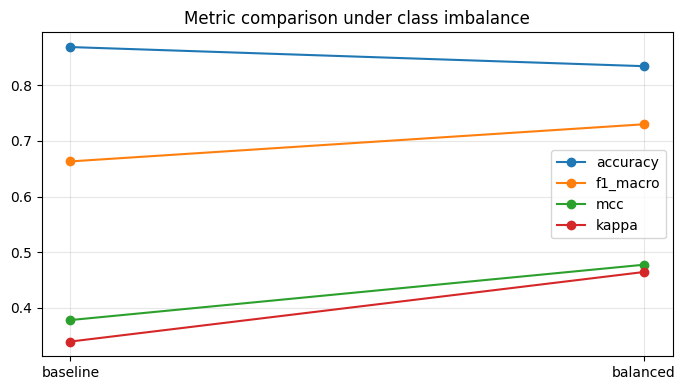

In [274]:
from sklearn.metrics import (matthews_corrcoef, cohen_kappa_score)

models = {
    "baseline": model,
    "balanced": model_w
}

results = {
    "name": [],
    "accuracy": [],
    "f1_macro": [],
    "mcc": [],
    "kappa": []
}

for name, m in models.items():
    pred = m.predict(X_test)

    results["name"].append(name)
    results["accuracy"].append(accuracy_score(y_test_b, pred))
    results["f1_macro"].append(f1_score(y_test_b, pred, average="macro"))
    results["mcc"].append(matthews_corrcoef(y_test_b, pred))
    results["kappa"].append(cohen_kappa_score(y_test_b, pred))

metrics = ["accuracy", "f1_macro", "mcc", "kappa"]

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

x = range(len(results["name"]))

for metric in metrics:
    ax.plot(x, results[metric], marker="o", label=metric)

ax.set_xticks(x)
ax.set_xticklabels(results["name"])
ax.set_title("Metric comparison under class imbalance")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Accuracy упала, потому что модель перестала стараться угадать и стала чаще ошибаться на доминирующем классе. При этом F1, MCC и Kappa выросли, что означает более честное и сбалансированное качество предсказаний по всем классам, а не только по частым.

MCC и Cohen’s Kappa используются как более устойчивые метрики при дисбалансе классов, поскольку учитывают все элементы матрицы корреляций и корректируют результат с учётом случайных совпадений. В отличие от accuracy, они дают более сбалансированную оценку качества модели при неравномерных классах.

Задание: оцените качество моделей с семплингом

In [275]:
from sklearn.metrics import f1_score, matthews_corrcoef, cohen_kappa_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.neighbors import NearestNeighbors

def manual_smote_func(X, y, seed=SEED, k=5):
    rng = np.random.RandomState(seed)
    X_min = X[y == 1].values
    n_target = np.sum(y == 0) - np.sum(y == 1)
    
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]
    
    synthetic = []
    for _ in range(n_target):
        idx = rng.randint(0, len(X_min))
        neighbor_idx = rng.choice(neighbors[idx])
        diff = X_min[neighbor_idx] - X_min[idx]
        new_point = X_min[idx] + rng.rand() * diff
        synthetic.append(new_point)
    
    X_res = np.vstack([X.values, np.array(synthetic)])
    y_res = np.hstack([y.values, np.ones(n_target, dtype=int)])
    return X_res, y_res

samplers = {
    "No sampling": None,
    "RandomOverSampler": RandomOverSampler(random_state=SEED),
    "SMOTE": SMOTE(k_neighbors=5, random_state=SEED),
    "Manual SMOTE": "manual"
}

results = []

for name, sampler in samplers.items():
    if name == "Manual SMOTE":
        X_res, y_res = manual_smote_func(X_train, y_train_b)
    elif sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train_b)
    else:
        X_res, y_res = X_train, y_train_b
    
    model = DecisionTreeClassifier(max_depth=6, random_state=SEED)
    model.fit(X_res, y_res)
    pred = model.predict(X_test)
    
    results.append({
        "Sampler": name,
        "F1-macro": f1_score(y_test_b, pred, average='macro'),
        "MCC": matthews_corrcoef(y_test_b, pred),
        "Cohen Kappa": cohen_kappa_score(y_test_b, pred),
    })

import pandas as pd
df_results = pd.DataFrame(results).round(4)
df_results

c:\Users\Slava Bek\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,Sampler,F1-macro,MCC,Cohen Kappa
0,No sampling,0.6638,0.3613,0.3368
1,RandomOverSampler,0.6855,0.4078,0.3834
2,SMOTE,0.6906,0.4054,0.3890
3,Manual SMOTE,0.7136,0.4559,0.4354


In [276]:

def plot_metrics_vs_threshold(
    model,
    X,
    y,
    X_val=None,
    y_val=None,
    use_cv=True,
    cv=10,
    thresholds=np.linspace(0, 1, 101),
    figsize=(12, 4),
    title_prefix=""
):
    if use_cv:
        proba_val = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
        y_val = y  # метки те же, что и для обучения (кросс-валидация даёт честные предсказания)
    else:
        model.fit(X, y)
        proba_val = model.predict_proba(X_val)[:, 1]

    metrics = [accuracy_score, balanced_accuracy_score, f1_score]
    metric_names = [m.__name__ for m in metrics]
    scores = {name: [] for name in metric_names}
    
    for t in thresholds:
        preds = (proba_val > t).astype(int)
        for m, name in zip(metrics, metric_names):
            scores[name].append(m(y_val, preds))
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, name in zip(axes, metric_names):
        ax.plot(thresholds, scores[name], label=name, color='blue')
        best_idx = np.argmax(scores[name])
        best_t = thresholds[best_idx]
        best_val = scores[name][best_idx]
        ax.axvline(best_t, color='red', linestyle='--', label=f'opt = {best_t:.3f}')
        ax.set_title(f'{name}\nopt value = {best_val:.3f}')
        ax.set_xlabel('threshold')
        ax.set_ylabel('score')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"{title_prefix}Зависимость метрик от порога", y=1.05)
    plt.tight_layout()
    plt.show()

Посмотрим, как меняются метрики при выборе порога.

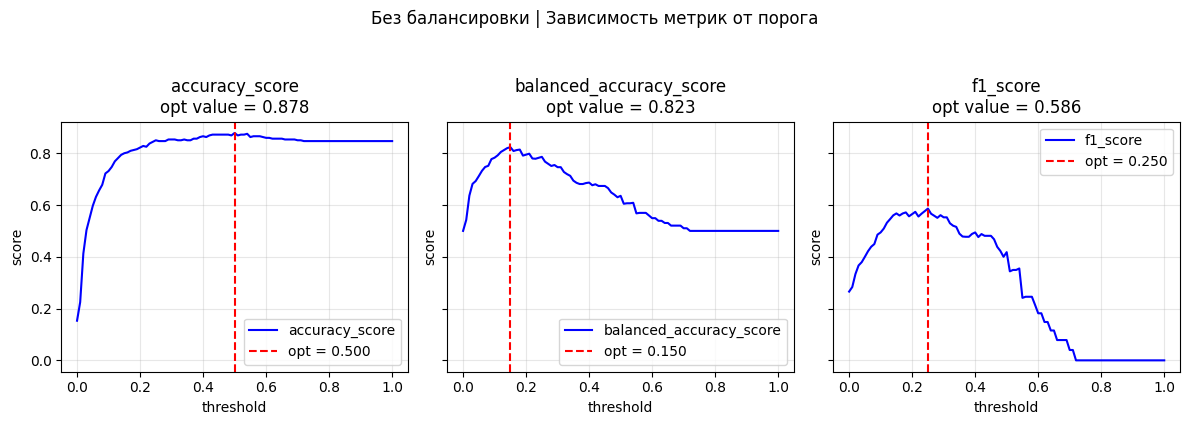

In [277]:

model = RandomForestClassifier(max_depth=5)
model_w =  RandomForestClassifier(max_depth=5, class_weight='balanced')

plot_metrics_vs_threshold(
    model, X_train, y_train_b, X_val=X_test, y_val=y_test_b,
    use_cv=False, title_prefix="Без балансировки | "
)


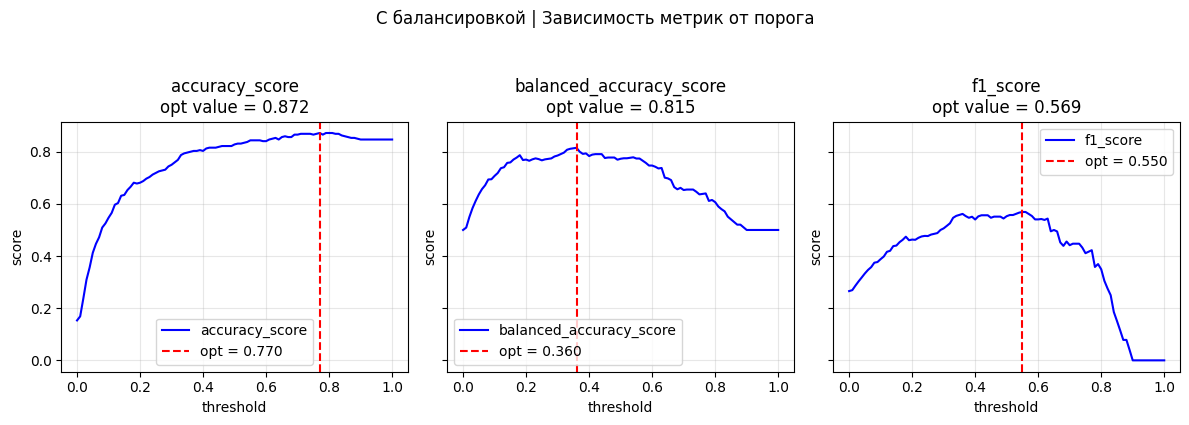

In [278]:

plot_metrics_vs_threshold(
    model_w, X_train, y_train_b, X_val=X_test, y_val=y_test_b,
    use_cv=False, title_prefix="С балансировкой | "
)


Как видно, после балансировки графики более "растянутые", при этом оптимальные пороги правее исходных. Почему это логично?